# Q2 历史窗口 \(W\) 敏感性分析

本 Notebook **只分析历史滚动窗口长度 \(W\)**，不重新调其他参数。

固定最终结构：

- \(K_L=3,\ K_P=2\)
- \(h_d^L=[s^L_{d-1},s^L_{d-7}]\)
- \(h_d^P=[s^P_{d-1},s^P_{d-7},\bar{s}^P_{d-7:d-1}]\)
- Load calendar：Fri/Sat 与其他日期
- PV calendar：年周期一阶 Fourier 编码
- \(lpha_L=3,\ lpha_P=30\)
- 概率层：28 日成对残差场景 + 14 日滚动共形校准

仅比较：

\[
W\in\{30,60,90,120\}.
\]

目的：检验模型对历史窗口长度的敏感性，并观察负荷、光伏和净负荷是否存在不同的最优历史尺度。


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

ROOT = Path.cwd()
summary = pd.read_csv(ROOT / "window_sensitivity_summary.csv")
daily = pd.read_csv(ROOT / "window_sensitivity_daily.csv")

# 中文字体：优先使用系统自带中文字体；本机 Windows 通常会自动命中微软雅黑/黑体。
candidates = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC", "Arial Unicode MS"]
font_names = {f.name for f in fm.fontManager.ttflist}
for name in candidates:
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name]
        break
plt.rcParams["axes.unicode_minus"] = False

summary.round(4)


,window_days,period,load_mae_kw,load_rmse_kw,pv_mae_kw,pv_rmse_kw,net_mae_kw,net_rmse_kw,crps_kw,cover80,cover90,width80_kw,width90_kw,qhat80_kw,qhat90_kw,runtime_sec
0,30,validation,143.2686,191.4811,180.0713,335.0442,262.5277,380.9714,189.3395,0.7989,0.8989,841.7956,1111.3146,47.0111,84.2686,3.6424
1,30,holdout,134.6242,187.0749,125.8734,252.5888,215.7306,317.6611,154.0801,0.8087,0.9007,711.0944,946.6950,27.8672,52.5995,3.7525
2,60,validation,127.2585,164.7877,177.8873,330.9772,251.0853,367.0960,178.9609,0.7996,0.8987,789.1573,1027.4480,41.1580,73.1901,18.8524
3,60,holdout,119.4029,160.7219,125.6436,252.6859,207.1158,305.4424,148.3877,0.8085,0.9015,688.2637,893.1190,29.6149,50.1355,18.8874
4,90,validation,127.5023,166.9923,181.6699,333.7772,253.2151,368.2361,179.3609,0.8006,0.8990,797.6845,1034.8300,43.2423,74.2571,3.6636
5,90,holdout,117.9174,156.1721,132.8685,259.4493,211.0549,304.2221,145.2223,0.8037,0.9007,664.6746,866.1162,29.1919,50.8239,3.7010
6,120,validation,127.3425,167.7725,181.7607,333.9596,254.8331,370.3692,180.2054,0.7984,0.8969,795.4860,1037.7540,41.9022,75.1713,5.0124
7,120,holdout,115.3322,153.6255,135.1484,261.3003,210.7998,304.3880,144.4079,0.8046,0.9014,659.5971,866.4954,29.1992,53.7639,5.0527


## 1. 汇总结果

分别观察模型选择区（validation）和独立测试区（holdout）。  
参数选择时应优先依据 validation，而不能根据 holdout 反向选择参数。


In [3]:
display_cols = [
    "window_days","period","load_rmse_kw","pv_rmse_kw",
    "net_mae_kw","net_rmse_kw","crps_kw",
    "cover80","cover90","width80_kw","width90_kw"
]
display(summary[display_cols].round(4))


,window_days,period,load_rmse_kw,pv_rmse_kw,net_mae_kw,net_rmse_kw,crps_kw,cover80,cover90,width80_kw,width90_kw
0,30,validation,191.4811,335.0442,262.5277,380.9714,189.3395,0.7989,0.8989,841.7956,1111.3146
1,30,holdout,187.0749,252.5888,215.7306,317.6611,154.0801,0.8087,0.9007,711.0944,946.6950
2,60,validation,164.7877,330.9772,251.0853,367.0960,178.9609,0.7996,0.8987,789.1573,1027.4480
3,60,holdout,160.7219,252.6859,207.1158,305.4424,148.3877,0.8085,0.9015,688.2637,893.1190
4,90,validation,166.9923,333.7772,253.2151,368.2361,179.3609,0.8006,0.8990,797.6845,1034.8300
5,90,holdout,156.1721,259.4493,211.0549,304.2221,145.2223,0.8037,0.9007,664.6746,866.1162
6,120,validation,167.7725,333.9596,254.8331,370.3692,180.2054,0.7984,0.8969,795.4860,1037.7540
7,120,holdout,153.6255,261.3003,210.7998,304.3880,144.4079,0.8046,0.9014,659.5971,866.4954


## 2. 净负荷 RMSE 随窗口长度变化

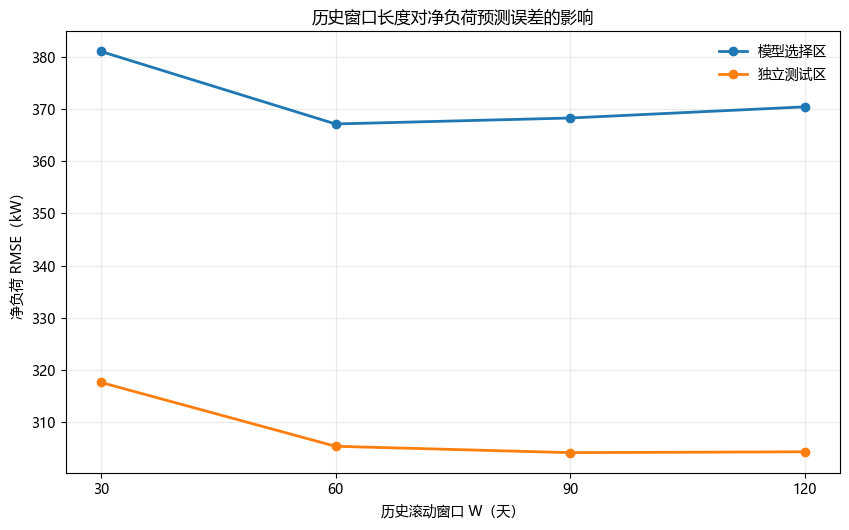

In [4]:
fig, ax = plt.subplots(figsize=(8.6,5.4))
for period, label in [("validation","模型选择区"),("holdout","独立测试区")]:
    d = summary[summary.period.eq(period)].sort_values("window_days")
    ax.plot(d.window_days, d.net_rmse_kw, marker="o", linewidth=2, label=label)
ax.set_xlabel("历史滚动窗口 W（天）")
ax.set_ylabel("净负荷 RMSE（kW）")
ax.set_title("历史窗口长度对净负荷预测误差的影响")
ax.set_xticks([30,60,90,120])
ax.grid(alpha=.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**阅读方式：**

- \(W=30\to60\)：误差下降明显；
- \(W=60\to90\to120\)：进入平台区；
- 因此模型并不对窗口长度极端敏感，但 30 天历史相对偏短。


## 3. Load / PV / Net 对窗口长度的敏感性

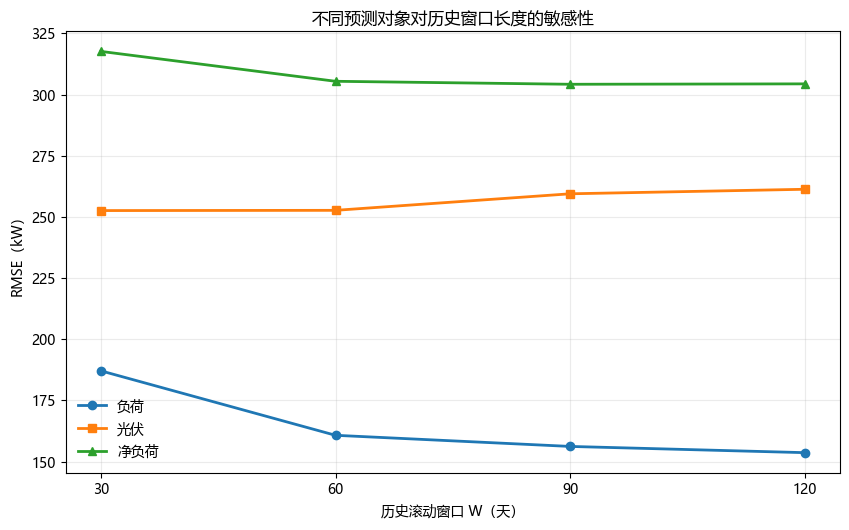

In [5]:
hold = summary[summary.period.eq("holdout")].sort_values("window_days")

fig, ax = plt.subplots(figsize=(8.6,5.4))
ax.plot(hold.window_days, hold.load_rmse_kw, marker="o", linewidth=2, label="负荷")
ax.plot(hold.window_days, hold.pv_rmse_kw, marker="s", linewidth=2, label="光伏")
ax.plot(hold.window_days, hold.net_rmse_kw, marker="^", linewidth=2, label="净负荷")
ax.set_xlabel("历史滚动窗口 W（天）")
ax.set_ylabel("RMSE（kW）")
ax.set_title("不同预测对象对历史窗口长度的敏感性")
ax.set_xticks([30,60,90,120])
ax.grid(alpha=.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


这里应重点观察：

- Load 随 \(W\) 增大明显受益，说明较长历史提高 PCA/Ridge 参数估计稳定性；
- PV 在窗口过长时并未持续改善，提示光伏存在更明显的季节漂移与近期适应需求；
- Net Load 因两者叠加，最终呈现“先改善、后平台”的折中形态。


## 4. 概率区间覆盖率

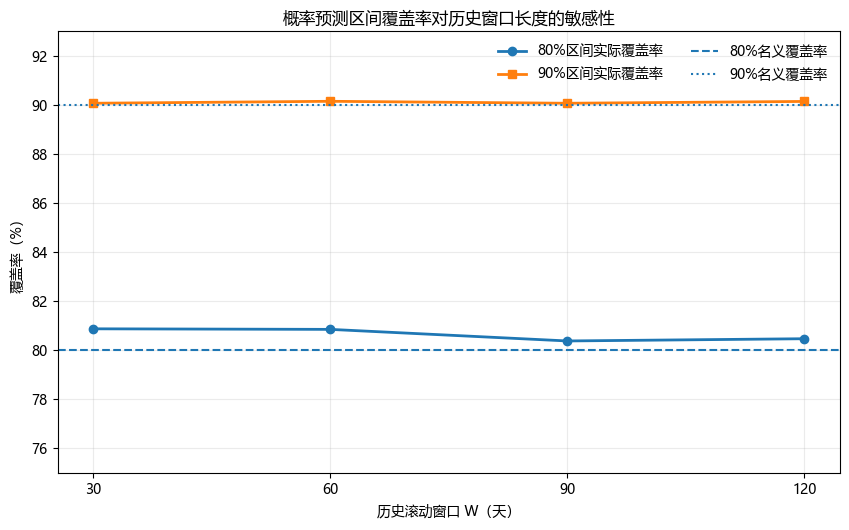

In [6]:
fig, ax = plt.subplots(figsize=(8.6,5.4))
ax.plot(hold.window_days, hold.cover80*100, marker="o", linewidth=2, label="80%区间实际覆盖率")
ax.plot(hold.window_days, hold.cover90*100, marker="s", linewidth=2, label="90%区间实际覆盖率")
ax.axhline(80, linestyle="--", linewidth=1.5, label="80%名义覆盖率")
ax.axhline(90, linestyle=":", linewidth=1.5, label="90%名义覆盖率")
ax.set_xlabel("历史滚动窗口 W（天）")
ax.set_ylabel("覆盖率（%）")
ax.set_title("概率预测区间覆盖率对历史窗口长度的敏感性")
ax.set_xticks([30,60,90,120])
ax.set_ylim(75,93)
ax.grid(alpha=.25)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


## 5. CRPS 与区间宽度

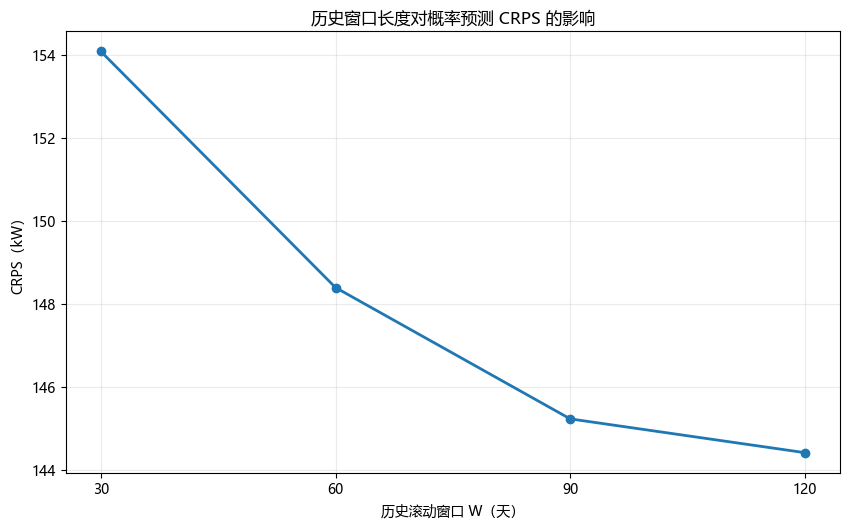

In [7]:
fig, ax = plt.subplots(figsize=(8.6,5.4))
ax.plot(hold.window_days, hold.crps_kw, marker="o", linewidth=2)
ax.set_xlabel("历史滚动窗口 W（天）")
ax.set_ylabel("CRPS（kW）")
ax.set_title("历史窗口长度对概率预测 CRPS 的影响")
ax.set_xticks([30,60,90,120])
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()


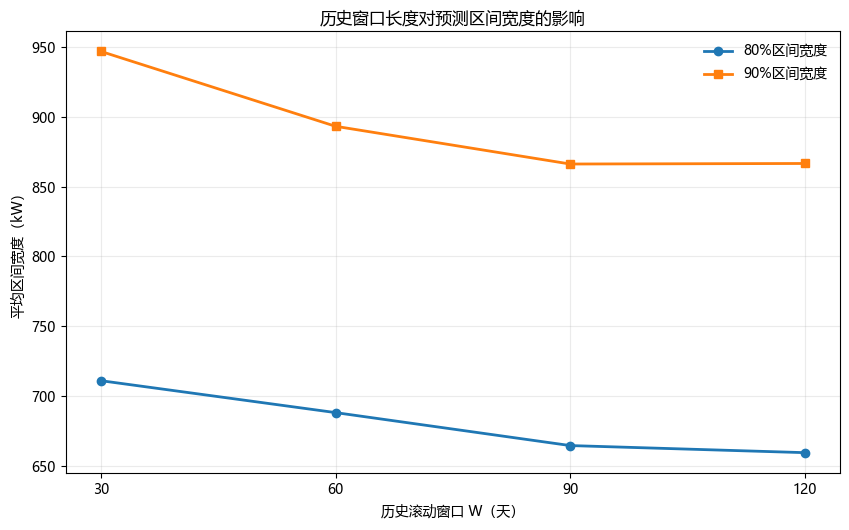

In [8]:
fig, ax = plt.subplots(figsize=(8.6,5.4))
ax.plot(hold.window_days, hold.width80_kw, marker="o", linewidth=2, label="80%区间宽度")
ax.plot(hold.window_days, hold.width90_kw, marker="s", linewidth=2, label="90%区间宽度")
ax.set_xlabel("历史滚动窗口 W（天）")
ax.set_ylabel("平均区间宽度（kW）")
ax.set_title("历史窗口长度对预测区间宽度的影响")
ax.set_xticks([30,60,90,120])
ax.grid(alpha=.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 6. 结论

从模型选择区结果看，\(W=60\) 的净负荷 RMSE 最低；继续增大至 90 或 120 天时性能变化较小。

因此敏感性分析支持以下结论：

> 当历史窗口由 30 天增加至 60 天时，模型精度明显提升；继续增大窗口后总体性能趋于稳定，说明模型在 60–120 天范围内对窗口长度具有较好的鲁棒性。较长窗口有利于负荷模型的稳定估计，而光伏序列对近期季节变化更敏感，因此过长窗口并未持续带来收益。

注意：若本阶段仅作为“敏感性分析”，可以暂时不修改主模型文件；是否正式采用 \(W=60\) 由建模组统一决定。
